## 1. Kurulum

In [1]:
# Colab'da çalıştırılırken paket kurulumu
!pip install -q transformers datasets accelerate scikit-learn matplotlib seaborn

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print(f'Colab: {IN_COLAB}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab: True


In [3]:
import os, json, pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, DataCollatorWithPadding,
                          EarlyStoppingCallback)
import transformers
transformers.logging.set_verbosity_error()

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 2. Yollar


In [4]:
if IN_COLAB:
    BASE = Path('/content/drive/MyDrive/bitirme/sentiment')
    REVIEWS_CSV = Path('/content/drive/MyDrive/bitirme/data/processed/reviews_merged.csv')
else:
    BASE = Path('/Users/melihyelman/Desktop/bitirme/sentiment')
    REVIEWS_CSV = Path('/Users/melihyelman/Desktop/bitirme/data/processed/reviews_merged.csv')

DATA_DIR = BASE / 'data'
MODEL_DIR = BASE / 'models'
OUTPUT_DIR = BASE / 'outputs'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'BASE        : {BASE}')
print(f'DATA_DIR    : {DATA_DIR}')
print(f'MODEL_DIR   : {MODEL_DIR}')
print(f'OUTPUT_DIR  : {OUTPUT_DIR}')
print(f'REVIEWS_CSV : {REVIEWS_CSV}')

BASE        : /content/drive/MyDrive/bitirme/sentiment
DATA_DIR    : /content/drive/MyDrive/bitirme/sentiment/data
MODEL_DIR   : /content/drive/MyDrive/bitirme/sentiment/models
OUTPUT_DIR  : /content/drive/MyDrive/bitirme/sentiment/outputs
REVIEWS_CSV : /content/drive/MyDrive/bitirme/data/processed/reviews_merged.csv


## 3. Yardımcı Fonksiyonlar

In [5]:
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight

def load_pkl(path):
    path = Path(path)
    if str(path).endswith('.csv'):
        df = pd.read_csv(path)
    else:
        with open(path, 'rb') as f:
            df = pickle.load(f)
    df = df.dropna(subset=['sentence', 'emotion']).reset_index(drop=True)
    df['sentence'] = df['sentence'].astype(str)
    return df

def make_splits(df, test_size=0.10, val_size=0.10, seed=SEED):
    le = LabelEncoder()
    df = df.copy()
    df['label'] = le.fit_transform(df['emotion'])
    train_val, test = train_test_split(df, test_size=test_size,
                                        stratify=df['label'], random_state=seed)
    train, val = train_test_split(train_val, test_size=val_size / (1 - test_size),
                                   stratify=train_val['label'], random_state=seed)
    print(f'Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}')
    print(f'Sınıflar ({len(le.classes_)}): {list(le.classes_)}')
    return train, val, test, le

def to_dataset(df, tokenizer, max_length=128):
    ds = Dataset.from_pandas(df[['sentence', 'label']].reset_index(drop=True))
    return ds.map(lambda x: tokenizer(x['sentence'], truncation=True,
                                       max_length=max_length, padding=False),
                  batched=True)

def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=1)
    labels = eval_pred.label_ids
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
        'f1_weighted': f1_score(labels, preds, average='weighted'),
    }

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.get('logits') if isinstance(outputs, dict) else outputs.logits
        if self.class_weights is not None:
            w = self.class_weights.to(logits.device)
            loss_fn = nn.CrossEntropyLoss(weight=w)
        else:
            loss_fn = nn.CrossEntropyLoss()
        loss = loss_fn(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def train_roberta(model_name, train_ds, val_ds, num_labels, ckpt_dir,
                   epochs=3, batch_size=None, lr=2e-5,
                   use_class_weights=True):
    import inspect

    use_fp16 = False
    use_bf16 = False
    default_bs = 16
    if torch.cuda.is_available():
        major, _ = torch.cuda.get_device_capability(0)
        if major >= 8:
            use_bf16 = True
            default_bs = 32
        else:
            use_fp16 = True
            default_bs = 16
    if batch_size is None:
        batch_size = default_bs

    class_weights = None
    if use_class_weights:
        train_labels = np.array(train_ds['label'])
        class_weights_np = compute_class_weight('balanced',
                                                 classes=np.arange(num_labels),
                                                 y=train_labels)
        class_weights = torch.tensor(class_weights_np, dtype=torch.float)
        print(f'Class weights: {dict(enumerate(class_weights_np.round(3)))}')
    else:
        print('Class weighting KAPALI — standart CrossEntropy')

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels)
    args = TrainingArguments(
        output_dir=str(ckpt_dir),
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        learning_rate=lr,
        warmup_ratio=0.1,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        fp16=use_fp16,
        bf16=use_bf16,
        logging_steps=100,
        save_total_limit=2,
        report_to='none',
        seed=42,
        dataloader_num_workers=2,
    )

    trainer_kwargs = dict(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
        class_weights=class_weights,
    )
    sig = inspect.signature(Trainer.__init__).parameters
    if 'processing_class' in sig:
        trainer_kwargs['processing_class'] = tokenizer
    else:
        trainer_kwargs['tokenizer'] = tokenizer
    trainer = WeightedTrainer(**trainer_kwargs)
    trainer.train()
    return trainer, model, tokenizer

def evaluate_on_test(trainer, test_ds, le, title='', save_path=None):
    pred = trainer.predict(test_ds)
    y_pred = np.argmax(pred.predictions, axis=1)
    y_true = pred.label_ids
    print(f'\n=== Test Sonuçları ({title}) ===')
    print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.xlabel('Tahmin'); plt.ylabel('Gerçek')
    plt.title(f'Confusion Matrix — {title}')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
    }

def save_model(model, tokenizer, le, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(out_dir)
    tokenizer.save_pretrained(out_dir)
    with open(out_dir / 'label_classes.json', 'w', encoding='utf-8') as f:
        json.dump(list(le.classes_), f, ensure_ascii=False, indent=2)
    print(f'Kaydedildi: {out_dir}')

## 4. Türkçe Model

In [6]:
TR_MODEL_NAME = 'burakaytan/roberta-base-turkish-uncased'
TR_OUT = MODEL_DIR / 'roberta_tr_final'

tr_df = load_pkl(DATA_DIR / 'türkçe_final.csv')
print(f'TR örnek: {len(tr_df):,}')
print(tr_df['emotion'].value_counts())

TR örnek: 12,000
emotion
anger        2000
disgust      2000
fear         2000
happiness    2000
sadness      2000
neutral      2000
Name: count, dtype: int64


In [7]:
tr_train, tr_val, tr_test, tr_le = make_splits(tr_df)
tr_tokenizer = AutoTokenizer.from_pretrained(TR_MODEL_NAME)
tr_train_ds = to_dataset(tr_train, tr_tokenizer)
tr_val_ds   = to_dataset(tr_val,   tr_tokenizer)
tr_test_ds  = to_dataset(tr_test,  tr_tokenizer)

Train: 9,600 | Val: 1,200 | Test: 1,200
Sınıflar (6): ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness']


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Map:   0%|          | 0/9600 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

In [8]:
tr_trainer, tr_model, tr_tokenizer = train_roberta(
    TR_MODEL_NAME, tr_train_ds, tr_val_ds,
    num_labels=len(tr_le.classes_),
    ckpt_dir=TR_OUT / 'checkpoints',
    epochs=3, batch_size=16, lr=2e-5,
)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0)}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

{'loss': '1.79', 'grad_norm': '0.7277', 'learning_rate': '1.1e-05', 'epoch': '0.1667'}
{'loss': '1.562', 'grad_norm': '9.798', 'learning_rate': '1.977e-05', 'epoch': '0.3333'}
{'loss': '0.9196', 'grad_norm': '7.466', 'learning_rate': '1.853e-05', 'epoch': '0.5'}
{'loss': '0.5237', 'grad_norm': '10.65', 'learning_rate': '1.73e-05', 'epoch': '0.6667'}
{'loss': '0.4253', 'grad_norm': '7.686', 'learning_rate': '1.606e-05', 'epoch': '0.8333'}
{'loss': '0.4008', 'grad_norm': '5.757', 'learning_rate': '1.483e-05', 'epoch': '1'}
{'eval_loss': '0.3643', 'eval_accuracy': '0.8908', 'eval_f1_macro': '0.8906', 'eval_f1_weighted': '0.8906', 'eval_runtime': '0.7976', 'eval_samples_per_second': '1505', 'eval_steps_per_second': '47.65', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.2822', 'grad_norm': '18.93', 'learning_rate': '1.359e-05', 'epoch': '1.167'}
{'loss': '0.271', 'grad_norm': '7.813', 'learning_rate': '1.236e-05', 'epoch': '1.333'}
{'loss': '0.2785', 'grad_norm': '15.75', 'learning_rate': '1.112e-05', 'epoch': '1.5'}
{'loss': '0.2872', 'grad_norm': '8.917', 'learning_rate': '9.889e-06', 'epoch': '1.667'}
{'loss': '0.2348', 'grad_norm': '4.235', 'learning_rate': '8.654e-06', 'epoch': '1.833'}
{'loss': '0.222', 'grad_norm': '17.29', 'learning_rate': '7.42e-06', 'epoch': '2'}
{'eval_loss': '0.2862', 'eval_accuracy': '0.9083', 'eval_f1_macro': '0.9082', 'eval_f1_weighted': '0.9082', 'eval_runtime': '0.7431', 'eval_samples_per_second': '1615', 'eval_steps_per_second': '51.14', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1663', 'grad_norm': '9.877', 'learning_rate': '6.185e-06', 'epoch': '2.167'}
{'loss': '0.1701', 'grad_norm': '10.85', 'learning_rate': '4.951e-06', 'epoch': '2.333'}
{'loss': '0.1793', 'grad_norm': '8.846', 'learning_rate': '3.716e-06', 'epoch': '2.5'}
{'loss': '0.1629', 'grad_norm': '10.37', 'learning_rate': '2.481e-06', 'epoch': '2.667'}
{'loss': '0.1981', 'grad_norm': '7.975', 'learning_rate': '1.247e-06', 'epoch': '2.833'}
{'loss': '0.1573', 'grad_norm': '3.676', 'learning_rate': '1.235e-08', 'epoch': '3'}
{'eval_loss': '0.3014', 'eval_accuracy': '0.9117', 'eval_f1_macro': '0.9115', 'eval_f1_weighted': '0.9115', 'eval_runtime': '0.7488', 'eval_samples_per_second': '1603', 'eval_steps_per_second': '50.75', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '96.72', 'train_samples_per_second': '297.8', 'train_steps_per_second': '18.61', 'train_loss': '0.4573', 'epoch': '3'}



=== Test Sonuçları (RoBERTa TR) ===
              precision    recall  f1-score   support

       anger     0.8638    0.9200    0.8910       200
     disgust     0.9272    0.9550    0.9409       200
        fear     0.9396    0.8550    0.8953       200
   happiness     0.9192    0.9100    0.9146       200
     neutral     1.0000    1.0000    1.0000       200
     sadness     0.8706    0.8750    0.8728       200

    accuracy                         0.9192      1200
   macro avg     0.9201    0.9192    0.9191      1200
weighted avg     0.9201    0.9192    0.9191      1200



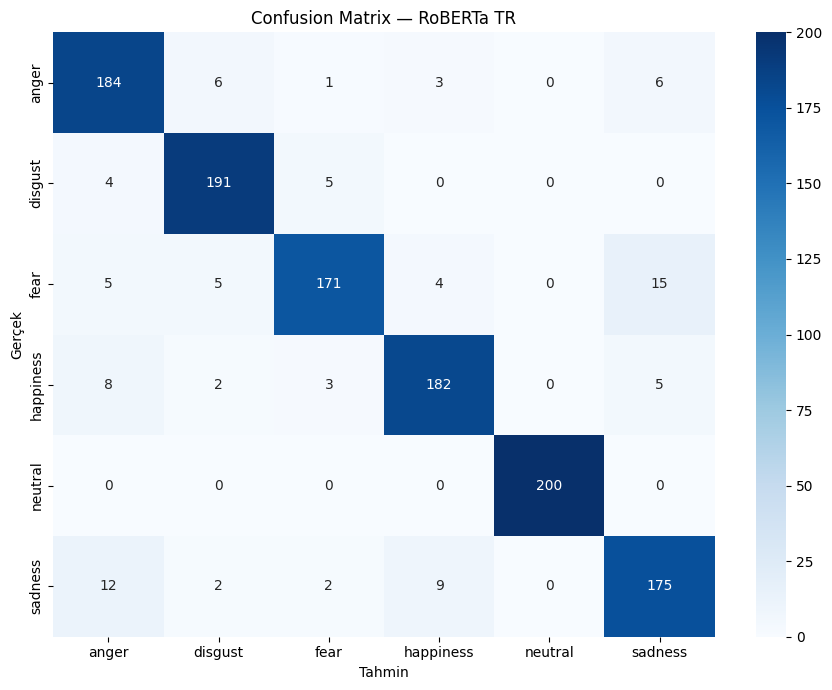

{'accuracy': 0.9191666666666667, 'f1_macro': 0.9191011065473337, 'f1_weighted': 0.9191011065473337}


In [9]:
tr_metrics = evaluate_on_test(tr_trainer, tr_test_ds, tr_le,
                               title='RoBERTa TR',
                               save_path=OUTPUT_DIR / 'roberta_tr_confusion.png')
print(tr_metrics)

In [10]:
save_model(tr_model, tr_tokenizer, tr_le, TR_OUT)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Kaydedildi: /content/drive/MyDrive/bitirme/sentiment/models/roberta_tr_final


## 5. İngilizce Model

In [11]:
EN_MODEL_NAME = 'roberta-base'
EN_OUT = MODEL_DIR / 'roberta_en_final'

en_df = load_pkl(DATA_DIR / 'ingilizce_final.csv')
print(f'EN örnek: {len(en_df):,}')
print(en_df['emotion'].value_counts())

EN örnek: 9,000
emotion
anger        1500
disgust      1500
fear         1500
happiness    1500
neutral      1500
sadness      1500
Name: count, dtype: int64


In [12]:
en_train, en_val, en_test, en_le = make_splits(en_df)
en_tokenizer = AutoTokenizer.from_pretrained(EN_MODEL_NAME)
en_train_ds = to_dataset(en_train, en_tokenizer)
en_val_ds   = to_dataset(en_val,   en_tokenizer)
en_test_ds  = to_dataset(en_test,  en_tokenizer)

Train: 7,199 | Val: 901 | Test: 900
Sınıflar (6): ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness']


Map:   0%|          | 0/7199 [00:00<?, ? examples/s]

Map:   0%|          | 0/901 [00:00<?, ? examples/s]

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

In [13]:
en_trainer, en_model, en_tokenizer = train_roberta(
    EN_MODEL_NAME, en_train_ds, en_val_ds,
    num_labels=len(en_le.classes_),
    ckpt_dir=EN_OUT / 'checkpoints',
    epochs=3, batch_size=16, lr=2e-5,
)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.001), 4: np.float64(1.0), 5: np.float64(1.0)}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

{'loss': '1.793', 'grad_norm': '2.283', 'learning_rate': '1.467e-05', 'epoch': '0.2222'}
{'loss': '1.319', 'grad_norm': '26.12', 'learning_rate': '1.895e-05', 'epoch': '0.4444'}
{'loss': '0.8735', 'grad_norm': '8.416', 'learning_rate': '1.73e-05', 'epoch': '0.6667'}
{'loss': '0.8749', 'grad_norm': '12.85', 'learning_rate': '1.565e-05', 'epoch': '0.8889'}
{'eval_loss': '0.7241', 'eval_accuracy': '0.7647', 'eval_f1_macro': '0.7649', 'eval_f1_weighted': '0.7651', 'eval_runtime': '0.6222', 'eval_samples_per_second': '1448', 'eval_steps_per_second': '46.61', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.7408', 'grad_norm': '20.91', 'learning_rate': '1.401e-05', 'epoch': '1.111'}
{'loss': '0.6608', 'grad_norm': '29.78', 'learning_rate': '1.236e-05', 'epoch': '1.333'}
{'loss': '0.5932', 'grad_norm': '24.9', 'learning_rate': '1.072e-05', 'epoch': '1.556'}
{'loss': '0.6666', 'grad_norm': '40.64', 'learning_rate': '9.07e-06', 'epoch': '1.778'}
{'loss': '0.5818', 'grad_norm': '13.11', 'learning_rate': '7.424e-06', 'epoch': '2'}
{'eval_loss': '0.6685', 'eval_accuracy': '0.778', 'eval_f1_macro': '0.7732', 'eval_f1_weighted': '0.7733', 'eval_runtime': '0.6466', 'eval_samples_per_second': '1393', 'eval_steps_per_second': '44.85', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.4575', 'grad_norm': '39.42', 'learning_rate': '5.778e-06', 'epoch': '2.222'}
{'loss': '0.4327', 'grad_norm': '28.9', 'learning_rate': '4.132e-06', 'epoch': '2.444'}
{'loss': '0.4521', 'grad_norm': '18.87', 'learning_rate': '2.486e-06', 'epoch': '2.667'}
{'loss': '0.4177', 'grad_norm': '18.72', 'learning_rate': '8.395e-07', 'epoch': '2.889'}
{'eval_loss': '0.6719', 'eval_accuracy': '0.7791', 'eval_f1_macro': '0.7738', 'eval_f1_weighted': '0.7739', 'eval_runtime': '0.6877', 'eval_samples_per_second': '1310', 'eval_steps_per_second': '42.17', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '77.17', 'train_samples_per_second': '279.9', 'train_steps_per_second': '17.49', 'train_loss': '0.747', 'epoch': '3'}



=== Test Sonuçları (RoBERTa EN) ===
              precision    recall  f1-score   support

       anger     0.6370    0.6200    0.6284       150
     disgust     0.7988    0.9000    0.8464       150
        fear     0.8780    0.9600    0.9172       150
   happiness     0.8981    0.9400    0.9186       150
     neutral     0.7025    0.5667    0.6273       150
     sadness     0.7273    0.6933    0.7099       150

    accuracy                         0.7800       900
   macro avg     0.7736    0.7800    0.7746       900
weighted avg     0.7736    0.7800    0.7746       900



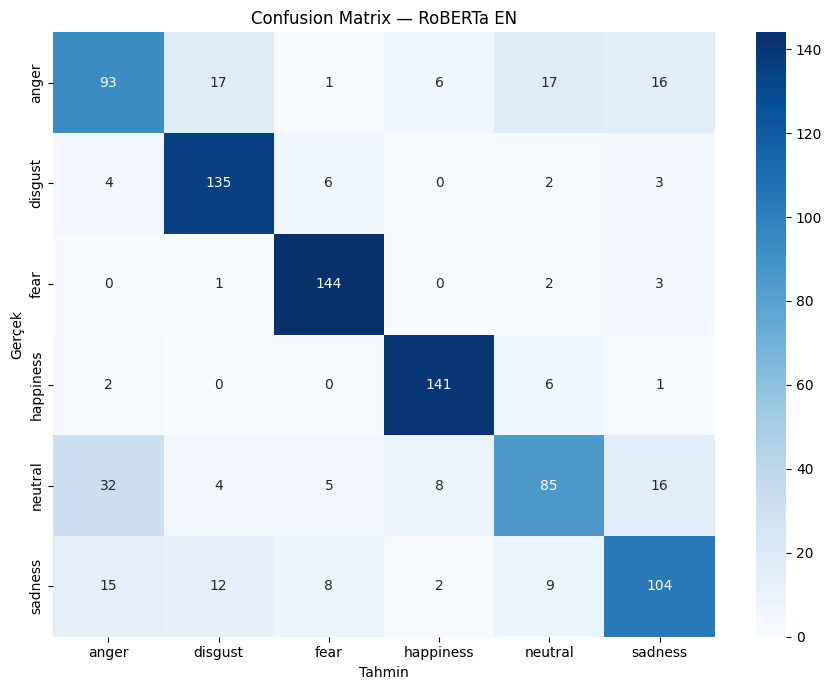

{'accuracy': 0.78, 'f1_macro': 0.774623579027038, 'f1_weighted': 0.7746235790270382}


In [14]:
en_metrics = evaluate_on_test(en_trainer, en_test_ds, en_le,
                               title='RoBERTa EN',
                               save_path=OUTPUT_DIR / 'roberta_en_confusion.png')
print(en_metrics)

In [15]:
save_model(en_model, en_tokenizer, en_le, EN_OUT)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Kaydedildi: /content/drive/MyDrive/bitirme/sentiment/models/roberta_en_final


## 6. Model Performans Özeti

In [16]:
summary = pd.DataFrame({
    'Model': ['RoBERTa TR (final-6)', 'RoBERTa EN (final-6)'],
    'Accuracy':    [tr_metrics['accuracy'],    en_metrics['accuracy']],
    'F1 (macro)':  [tr_metrics['f1_macro'],    en_metrics['f1_macro']],
    'F1 (weighted)':[tr_metrics['f1_weighted'], en_metrics['f1_weighted']],
})
summary.to_csv(OUTPUT_DIR / 'model_performans_ozeti_final.csv', index=False, encoding='utf-8-sig')
print(summary.to_string(index=False))

               Model  Accuracy  F1 (macro)  F1 (weighted)
RoBERTa TR (final-6)  0.919167    0.919101       0.919101
RoBERTa EN (final-6)  0.780000    0.774624       0.774624


## 7. Inference — Film Yorumlarına Duygu Etiketi


In [17]:
reviews_df = pd.read_csv(REVIEWS_CSV)
print(f'Yorum: {len(reviews_df):,} | Sütunlar: {list(reviews_df.columns)}')
print(reviews_df['language'].value_counts())

Yorum: 382,977 | Sütunlar: ['imdb_id', 'source', 'language', 'review_text', 'cleaned_text']
language
en    191562
tr    191415
Name: count, dtype: int64


In [18]:
@torch.no_grad()
def predict_batch(texts, model, tokenizer, le, batch_size=64, max_length=256):
    """Yorum listesi için duygu etiketleri döner."""
    model = model.to(DEVICE).eval()
    preds = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=max_length, return_tensors='pt').to(DEVICE)
        logits = model(**enc).logits
        preds.extend(logits.argmax(dim=-1).cpu().numpy().tolist())
        if (i // batch_size) % 20 == 0:
            print(f'  {i + len(batch):,} / {len(texts):,}')
    return [le.classes_[p] for p in preds]

In [19]:
reviews_df['sentiment'] = None

tr_mask = reviews_df['language'] == 'tr'
en_mask = reviews_df['language'] == 'en'

print(f'TR yorum etiketleniyor: {tr_mask.sum():,}')
tr_sent = predict_batch(reviews_df.loc[tr_mask, 'review_text'].astype(str).tolist(),
                         tr_model, tr_tokenizer, tr_le, batch_size=64)
reviews_df.loc[tr_mask, 'sentiment'] = tr_sent

print(f'\nEN yorum etiketleniyor: {en_mask.sum():,}')
en_sent = predict_batch(reviews_df.loc[en_mask, 'review_text'].astype(str).tolist(),
                         en_model, en_tokenizer, en_le, batch_size=64)
reviews_df.loc[en_mask, 'sentiment'] = en_sent

TR yorum etiketleniyor: 191,415
  64 / 191,415
  1,344 / 191,415
  2,624 / 191,415
  3,904 / 191,415
  5,184 / 191,415
  6,464 / 191,415
  7,744 / 191,415
  9,024 / 191,415
  10,304 / 191,415
  11,584 / 191,415
  12,864 / 191,415
  14,144 / 191,415
  15,424 / 191,415
  16,704 / 191,415
  17,984 / 191,415
  19,264 / 191,415
  20,544 / 191,415
  21,824 / 191,415
  23,104 / 191,415
  24,384 / 191,415
  25,664 / 191,415
  26,944 / 191,415
  28,224 / 191,415
  29,504 / 191,415
  30,784 / 191,415
  32,064 / 191,415
  33,344 / 191,415
  34,624 / 191,415
  35,904 / 191,415
  37,184 / 191,415
  38,464 / 191,415
  39,744 / 191,415
  41,024 / 191,415
  42,304 / 191,415
  43,584 / 191,415
  44,864 / 191,415
  46,144 / 191,415
  47,424 / 191,415
  48,704 / 191,415
  49,984 / 191,415
  51,264 / 191,415
  52,544 / 191,415
  53,824 / 191,415
  55,104 / 191,415
  56,384 / 191,415
  57,664 / 191,415
  58,944 / 191,415
  60,224 / 191,415
  61,504 / 191,415
  62,784 / 191,415
  64,064 / 191,415
  65,344 /

In [20]:
out_csv = OUTPUT_DIR / 'reviews_with_sentiment_final.csv'
reviews_df.to_csv(out_csv, index=False, encoding='utf-8-sig')
print(f'Kaydedildi: {out_csv}')
print()
print('Duygu × dil dağılımı:')
print(pd.crosstab(reviews_df['sentiment'], reviews_df['language'], margins=True))

Kaydedildi: /content/drive/MyDrive/bitirme/sentiment/outputs/reviews_with_sentiment_final.csv

Duygu × dil dağılımı:
language       en      tr     All
sentiment                        
anger       19352   58153   77505
disgust      5600    4713   10313
fear        10647    8733   19380
happiness   43557   71491  115048
neutral     81205    8846   90051
sadness     31201   39479   70680
All        191562  191415  382977
